In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [5]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import make_classification
X,y= make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [7]:
df=pd.DataFrame(X, columns=['col1','col2','col3','col4', 'col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.651233,0.612688,0.131693,-2.331416,-2.426458,1
1,3.404005,1.334016,1.680767,0.651919,-2.091082,0
2,-0.182016,1.716121,0.090185,-0.706735,-0.250847,1
3,4.131794,-1.124351,0.229464,-0.546853,-3.565985,0
4,0.998575,2.439107,2.174131,0.267173,-0.540318,0


In [18]:
#function for row sampling
def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [19]:
#function for feature(columns) sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [21]:
#function for combined sampling 
def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [26]:
import random
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_58/2846331670.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [27]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_58/2846331670.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [28]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_58/2846331670.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [29]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col4', 'target'], dtype='object')
Index(['col2', 'col4', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')


In [30]:
df3

,col3,col2,target
43,0.222206,-0.651709,0
31,-0.075025,0.333260,0
8,0.475677,1.589035,0
29,1.047384,0.715513,0
16,-0.063530,-0.081166,0
80,0.734003,0.094459,0
88,0.001813,0.004107,0
51,1.567711,0.858529,0
17,1.071171,2.547830,1
4,2.174131,2.439107,0


In [33]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [34]:

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [35]:
from sklearn.tree import plot_tree

[Text(0.3235294117647059, 0.9375, 'x[0] <= -0.054\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.11764705882352941, 0.8125, 'x[0] <= -1.385\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.22058823529411764, 0.875, 'True  '),
 Text(0.058823529411764705, 0.6875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.17647058823529413, 0.6875, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.5294117647058824, 0.8125, 'x[1] <= -0.955\ngini = 0.48\nsamples = 40\nvalue = [16, 24]'),
 Text(0.42647058823529416, 0.875, '  False'),
 Text(0.29411764705882354, 0.6875, 'x[1] <= -1.746\ngini = 0.397\nsamples = 22\nvalue = [6, 16]'),
 Text(0.23529411764705882, 0.5625, 'x[0] <= 0.007\ngini = 0.457\nsamples = 17\nvalue = [6, 11]'),
 Text(0.17647058823529413, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.29411764705882354, 0.4375, 'x[0] <= 0.491\ngini = 0.49\nsamples = 14\nvalue = [6, 8]'),
 Text(0.17647058823529413, 0.3125, 'x[0] <= 0.07\ngini = 0.32\nsamples = 5\nvalue = 

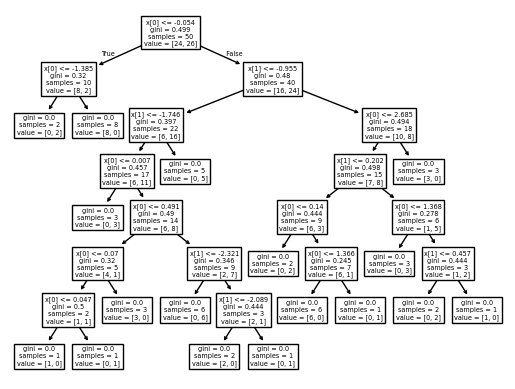

In [36]:
plot_tree(clf1)

[Text(0.28289473684210525, 0.9444444444444444, 'x[0] <= -0.428\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.23026315789473684, 0.8333333333333334, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.256578947368421, 0.8888888888888888, 'True  '),
 Text(0.3355263157894737, 0.8333333333333334, 'x[0] <= -0.065\ngini = 0.491\nsamples = 46\nvalue = [20.0, 26.0]'),
 Text(0.3092105263157895, 0.8888888888888888, '  False'),
 Text(0.15789473684210525, 0.7222222222222222, 'x[0] <= -0.179\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.10526315789473684, 0.6111111111111112, 'x[1] <= -2.133\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.05263157894736842, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.15789473684210525, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.21052631578947367, 0.6111111111111112, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.5131578947368421, 0.7222222222222222, 'x[0] <= 0.836\ngini = 0.498\nsamples = 36\nvalue = [19, 17]'

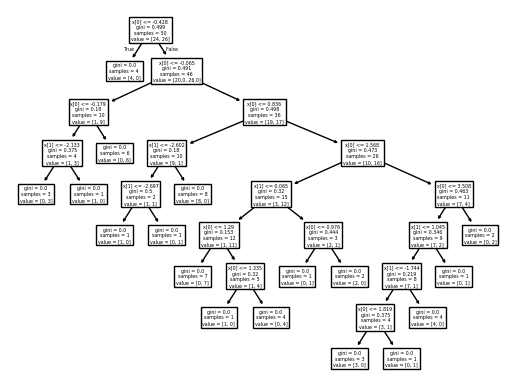

In [37]:
plot_tree(clf2)

[Text(0.6, 0.9375, 'x[0] <= 1.746\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.44, 0.8125, 'x[1] <= 1.653\ngini = 0.491\nsamples = 37\nvalue = [21, 16]'),
 Text(0.52, 0.875, 'True  '),
 Text(0.36, 0.6875, 'x[0] <= -0.215\ngini = 0.451\nsamples = 32\nvalue = [21, 11]'),
 Text(0.16, 0.5625, 'x[1] <= -0.357\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.08, 0.4375, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.24, 0.4375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.56, 0.5625, 'x[0] <= 0.775\ngini = 0.384\nsamples = 27\nvalue = [20, 7]'),
 Text(0.4, 0.4375, 'x[1] <= 0.577\ngini = 0.208\nsamples = 17\nvalue = [15, 2]'),
 Text(0.32, 0.3125, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.48, 0.3125, 'x[1] <= 1.046\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.4, 0.1875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.56, 0.1875, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.72, 0.4375, 'x[1] <= 0.293\ngini = 0.5\nsamples = 10\nvalue = [

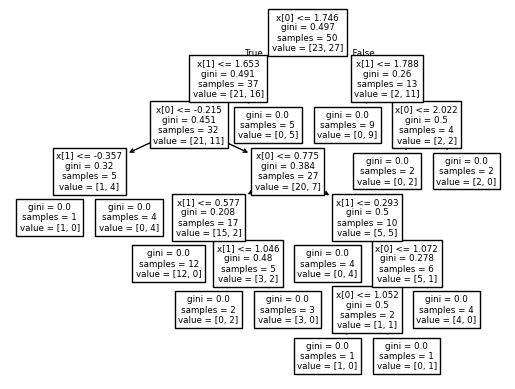

In [38]:
plot_tree(clf3)

In [43]:
clf1.predict(np.array([0.222206, -0.651709]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [44]:
clf2.predict(np.array([0.222206, -0.651709]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [45]:
clf3.predict(np.array([0.222206, -0.651709]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [46]:
df.sample(14, replace=True)

,col1,col2,col3,col4,col5,target
98,-0.808253,-1.443434,2.827398,-1.861623,-0.714966,1
43,-0.247633,-0.651709,0.222206,-2.201633,-0.835482,0
36,0.681732,1.345617,0.428764,-0.747367,0.575308,1
30,-2.605344,1.164220,2.043389,-1.601387,-2.292064,1
18,-1.847166,-0.176232,0.833753,-3.101731,-0.693499,1
24,2.775813,-0.094394,0.161528,-1.470789,-2.440576,0
58,4.422549,-1.940840,-0.338349,1.795124,-1.724616,0
30,-2.605344,1.164220,2.043389,-1.601387,-2.292064,1
58,4.422549,-1.940840,-0.338349,1.795124,-1.724616,0
29,0.964704,0.715513,1.047384,-0.141263,-0.504742,0
